In [1]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import shutil

from baseline_cnn import BaselineCNN
from utils import train, get_loaders

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


In [ ]:
# personal
#DATA_DIR = Path("../data")

#colab
#add cinic_data folder to personal google drive and drop the data downloaded from kaggle
from google.colab import drive
drive.mount('/content/drive')

#DATA_DIR = Path("/content/drive/MyDrive/cinic_data")
DATA_DIR = Path("/content/drive/MyDrive/cinic_subset")

if not os.path.exists('/content/cinic_subset'):
    print("Copying data from drive...", flush=True)
    shutil.copytree(DATA_DIR, '/content/cinic_subset')
    print("Done!", flush=True)
else:
    print("Data already exists locally!", flush=True)

DATA_DIR = Path("/content/cinic_subset")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"


In [95]:
BATCH_SIZE = 128
train_loader, valid_loader, test_loader = get_loaders(train_dir=TRAIN_DIR, valid_dir=VALID_DIR,
                                                      test_dir=TEST_DIR, image_size=224, batch_size=BATCH_SIZE)

## Baseline CNN

In [96]:
model = BaselineCNN(input_channels = 3, image_size=224, conv_channels =[32, 64, 128], kernel_sizes = [3,3, 3],
                    fc_layers = [512, 256, 10], num_classes = 10)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [97]:
model_history = train(model, train_loader, valid_loader, criterion, optimizer, device=device, \
          num_epochs=10, verbose=True, verbose_interval=1)

Epoch: 0
Epoch 1/10 | Train Loss: 2.0771 | Valid Loss: 1.8929 | Valid Acc: 0.2961
Epoch: 1
Epoch 2/10 | Train Loss: 1.7596 | Valid Loss: 1.7134 | Valid Acc: 0.3495
Epoch: 2
Epoch 3/10 | Train Loss: 1.5756 | Valid Loss: 1.6257 | Valid Acc: 0.3874
Epoch: 3
Epoch 4/10 | Train Loss: 1.3828 | Valid Loss: 1.6368 | Valid Acc: 0.4007
Epoch: 4
Epoch 5/10 | Train Loss: 1.1577 | Valid Loss: 1.7060 | Valid Acc: 0.4010
Epoch: 5
Epoch 6/10 | Train Loss: 0.8803 | Valid Loss: 2.0347 | Valid Acc: 0.4003
Epoch: 6
Epoch 7/10 | Train Loss: 0.5648 | Valid Loss: 2.5279 | Valid Acc: 0.4099
Epoch: 7
Epoch 8/10 | Train Loss: 0.3675 | Valid Loss: 3.0092 | Valid Acc: 0.3883
Epoch: 8
Epoch 9/10 | Train Loss: 0.2562 | Valid Loss: 3.7950 | Valid Acc: 0.4054
Epoch: 9
Epoch 10/10 | Train Loss: 0.1289 | Valid Loss: 4.5049 | Valid Acc: 0.3965
Best validation accuracy: 0.4099


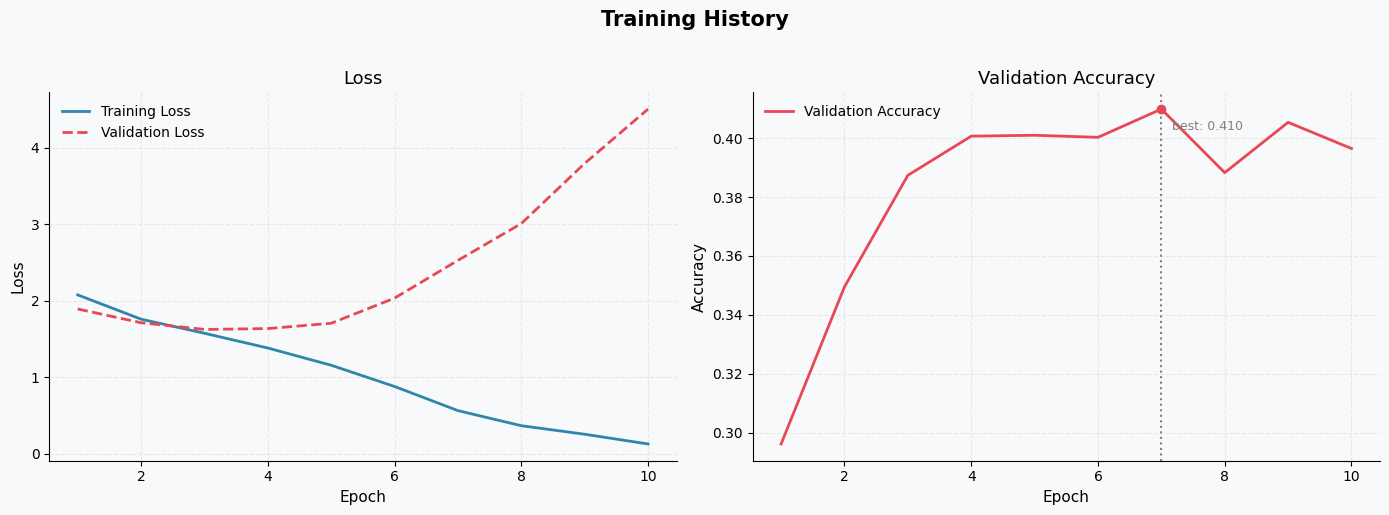

In [105]:
plot_training_history(model_history)